In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [14]:
def f(x):
    return np.sqrt(x)

def t_from_x(x): 
    return x - 1

def x_from_t(t): 
    return t + 1

In [15]:

def g(t):
    return f(x_from_t(t))

def T0(t): return 1.0
def T1(t): return t
def T2(t): return 2*t**2 - 1.0

In [16]:
def integrand_c0(theta):
    return g(np.cos(theta)) * T0(np.cos(theta))

def integrand_c1(theta):
    return g(np.cos(theta)) * T1(np.cos(theta))

def integrand_c2(theta):
    return g(np.cos(theta)) * T2(np.cos(theta))

In [17]:
c0_num = (1 / np.pi) * quad(integrand_c0, 0, np.pi)[0]
c1_num = (2 / np.pi) * quad(integrand_c1, 0, np.pi)[0]
c2_num = (2 / np.pi) * quad(integrand_c2, 0, np.pi)[0]

c0_teo = 2 * np.sqrt(2) / np.pi
c1_teo = 4 * np.sqrt(2) / (3 * np.pi)
c2_teo = 4 * np.sqrt(2) / (15 * np.pi)

In [18]:
print("--- Porównanie współczynników ---")
print(f"c0: Numerycznie = {c0_num:.6f} | Teoretycznie = {c0_teo:.6f}")
print(f"c1: Numerycznie = {c1_num:.6f} | Teoretycznie = {c1_teo:.6f}")
print(f"c2: Numerycznie = {c2_num:.6f} | Teoretycznie = {c2_teo:.6f}\n")

--- Porównanie współczynników ---
c0: Numerycznie = 0.900316 | Teoretycznie = 0.900316
c1: Numerycznie = 0.600211 | Teoretycznie = 0.600211
c2: Numerycznie = -0.120042 | Teoretycznie = 0.120042



In [19]:
def P2(x):
    t = t_from_x(x)
    return c0_num * T0(t) + c1_num * T1(t) + c2_num * T2(t)

In [20]:
x_vals = np.linspace(0, 2, 400)
f_vals = f(x_vals)
P2_vals = P2(x_vals)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\julo\AppData\Local\Temp\ipykernel_6084\3716333619.py:2: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x_vals, f_vals, label='$f(x) = \sqrt{x}$', color='blue', linewidth=2)


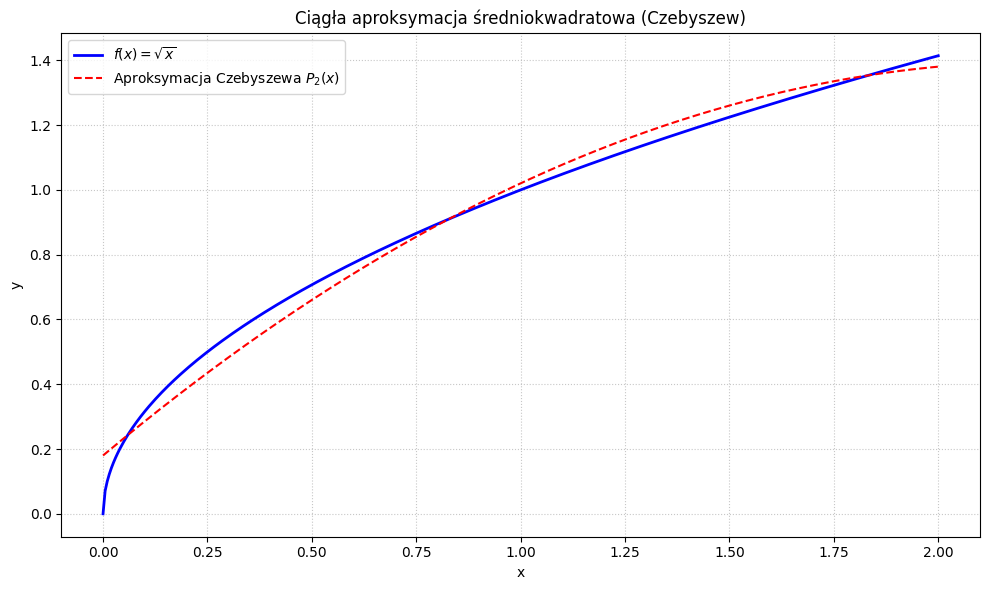

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(x_vals, f_vals, label='$f(x) = \sqrt{x}$', color='blue', linewidth=2)
plt.plot(x_vals, P2_vals, label='Aproksymacja Czebyszewa $P_2(x)$', color='red', linestyle='--')

plt.title('Ciągła aproksymacja średniokwadratowa (Czebyszew)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, ls=':', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.show()

In [22]:

print("--- Weryfikacja wartości ---")
for x_test in [0.0, 1.0, 2.0]:
    print(f"Dla x = {x_test}: F. org. = {f(x_test):.4f}, Aproksymacja = {P2(x_test):.4f}, Błąd = {abs(f(x_test) - P2(x_test)):.4f}")

--- Weryfikacja wartości ---
Dla x = 0.0: F. org. = 0.0000, Aproksymacja = 0.1801, Błąd = 0.1801
Dla x = 1.0: F. org. = 1.0000, Aproksymacja = 1.0204, Błąd = 0.0204
Dla x = 2.0: F. org. = 1.4142, Aproksymacja = 1.3805, Błąd = 0.0337
